# SagingSense PH: Banana Leaf Disease Classification Using Convolutional Neural Networks

This notebook builds a banana leaf disease image classifier for the SagingSense PH system.

## Goal

Classify banana leaf images into disease categories using a Convolutional Neural Network, or CNN.

## Workflow

1. Load the banana leaf disease dataset
2. Detect class folders automatically
3. Count images per class
4. Split data into training, validation, and testing sets
5. Apply augmentation only to the training set
6. Train a CNN model
7. Evaluate using accuracy, precision, recall, F1-score, and confusion matrix
8. Save the trained model for later Django integration

### Import Libraries

In [1]:
import os
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TensorFlow version: 2.18.0
GPU devices: []


## Set Dataset Path

In [2]:
# ============================================================
# DATASET PATH
# ============================================================
# Example Windows:
# DATASET_ROOT = Path(r"E:\Datasets\banana_leaf_disease")

# Example Kaggle:
# DATASET_ROOT = Path(r"/kaggle/input/banana-disease-recognition-dataset")

DATASET_ROOT = Path(r"kaggle/input/banana-disease-recognition-dataset")

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root does not exist: {DATASET_ROOT}\n"
        "Please update DATASET_ROOT to the correct folder."
    )

print("Dataset root:", DATASET_ROOT)

Dataset root: kaggle\input\banana-disease-recognition-dataset


## Inspect Top-Level Folder

In [3]:
print("Contents of dataset root:\n")

for item in DATASET_ROOT.iterdir():
    if item.is_dir():
        print("[DIR] ", item.name)
    else:
        print("[FILE]", item.name)

Contents of dataset root:

[DIR]  Augmented images
[DIR]  Original Images


## Auto-Detect the Actual Image Folder

In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TRAIN_VARIANT = "augmented"
EVAL_VARIANT = "original"


def normalize_class_name(class_name):
    normalized = class_name.strip()
    for prefix in ("Augmented ", "Original "):
        if normalized.startswith(prefix):
            normalized = normalized[len(prefix):]
    return normalized


def count_images_in_class_folders(folder):
    folder = Path(folder)
    total = 0
    raw_class_counts = {}
    canonical_class_counts = {}

    for subfolder in folder.iterdir():
        if subfolder.is_dir():
            image_count = sum(
                1
                for file in subfolder.iterdir()
                if file.suffix.lower() in IMAGE_EXTENSIONS
            )
            if image_count > 0:
                raw_class_counts[subfolder.name] = image_count
                canonical_name = normalize_class_name(subfolder.name)
                canonical_class_counts[canonical_name] = canonical_class_counts.get(canonical_name, 0) + image_count
                total += image_count

    return total, raw_class_counts, canonical_class_counts


def detect_dataset_variant(folder):
    folder_text = " ".join(part.lower() for part in folder.parts)
    if "augmented" in folder_text:
        return "augmented"
    if "original" in folder_text:
        return "original"
    return "unknown"


candidate_folders = []
all_dirs = [DATASET_ROOT] + [p for p in DATASET_ROOT.rglob("*") if p.is_dir()]

for folder in all_dirs:
    total_images, raw_class_counts, canonical_class_counts = count_images_in_class_folders(folder)
    if len(canonical_class_counts) >= 2 and total_images > 0:
        candidate_folders.append({
            "variant": detect_dataset_variant(folder),
            "folder": folder,
            "total_images": total_images,
            "raw_class_counts": raw_class_counts,
            "canonical_class_counts": canonical_class_counts,
        })

if not candidate_folders:
    raise ValueError(
        "No valid image folder was found. The dataset should contain class folders with images."
    )

variant_summary = pd.DataFrame([
    {
        "Variant": candidate["variant"],
        "Image Folder": str(candidate["folder"]),
        "Classes": len(candidate["canonical_class_counts"]),
        "Images": candidate["total_images"],
    }
    for candidate in candidate_folders
]).sort_values(["Variant", "Images"], ascending=[True, False])

print("Detected image folder variants:")
print(variant_summary.to_string(index=False))


def select_variant_candidate(variant):
    matching_candidates = [
        candidate for candidate in candidate_folders
        if candidate["variant"] == variant.lower()
    ]

    if not matching_candidates:
        available_variants = sorted(set(candidate["variant"] for candidate in candidate_folders))
        raise ValueError(
            f"Variant {variant!r} was not found. Available variants: {available_variants}"
        )

    return max(matching_candidates, key=lambda candidate: candidate["total_images"])


train_candidate = select_variant_candidate(TRAIN_VARIANT)
eval_candidate = select_variant_candidate(EVAL_VARIANT)

TRAIN_DATA_DIR = train_candidate["folder"]
EVAL_DATA_DIR = eval_candidate["folder"]
train_total_images = train_candidate["total_images"]
eval_total_images = eval_candidate["total_images"]
train_class_counts = train_candidate["canonical_class_counts"]
eval_class_counts = eval_candidate["canonical_class_counts"]

train_classes = set(train_class_counts)
eval_classes = set(eval_class_counts)
if train_classes != eval_classes:
    raise ValueError(
        "Training and evaluation variants do not have the same classes. "
        f"Only in train: {sorted(train_classes - eval_classes)}. "
        f"Only in eval: {sorted(eval_classes - train_classes)}."
    )

class_names = sorted(train_classes)
num_classes = len(class_names)
class_counts = train_class_counts
total_images = train_total_images + eval_total_images

print("\nTraining dataset variant:", TRAIN_VARIANT)
print("Training image data folder:")
print(TRAIN_DATA_DIR)

print("\nEvaluation dataset variant:", EVAL_VARIANT)
print("Evaluation image data folder:")
print(EVAL_DATA_DIR)

print("\nCanonical classes:")
for class_name in class_names:
    print(
        f"{class_name}: "
        f"{train_class_counts[class_name]} training images, "
        f"{eval_class_counts[class_name]} evaluation images"
    )

print("\nTraining images detected:", train_total_images)
print("Evaluation images detected:", eval_total_images)
print("Total images detected:", total_images)
print("Number of classes:", num_classes)

Detected image folder variants:
  Variant                                                                      Image Folder  Classes  Images
augmented kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images        7    2856
 original   kaggle\input\banana-disease-recognition-dataset\Original Images\Original Images        7     408

Training dataset variant: augmented
Training image data folder:
kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images

Evaluation dataset variant: original
Evaluation image data folder:
kaggle\input\banana-disease-recognition-dataset\Original Images\Original Images

Canonical classes:
Banana Black Sigatoka Disease: 469 training images, 67 evaluation images
Banana Bract Mosaic Virus Disease: 350 training images, 50 evaluation images
Banana Healthy Leaf: 602 training images, 86 evaluation images
Banana Insect Pest Disease: 602 training images, 86 evaluation images
Banana Moko Disease: 385 training images, 5

## Dataset Summary Table

                            Class  Training Image Count  Evaluation Image Count  Total Image Count  Training Percentage  Evaluation Percentage
    Banana Black Sigatoka Disease                   469                      67                536                16.42                  16.42
Banana Bract Mosaic Virus Disease                   350                      50                400                12.25                  12.25
              Banana Healthy Leaf                   602                      86                688                21.08                  21.08
       Banana Insect Pest Disease                   602                      86                688                21.08                  21.08
              Banana Moko Disease                   385                      55                440                13.48                  13.48
            Banana Panama Disease                   287                      41                328                10.05                  10.05

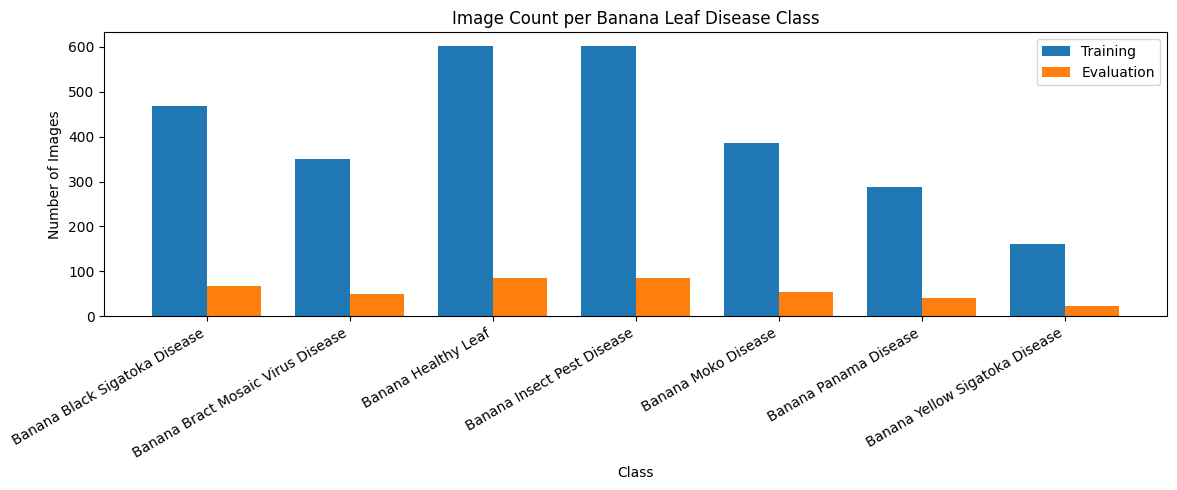

In [5]:
dataset_summary = pd.DataFrame({
    "Class": class_names,
    "Training Image Count": [train_class_counts[class_name] for class_name in class_names],
    "Evaluation Image Count": [eval_class_counts[class_name] for class_name in class_names],
})

dataset_summary["Total Image Count"] = (
    dataset_summary["Training Image Count"] + dataset_summary["Evaluation Image Count"]
)
dataset_summary["Training Percentage"] = (
    dataset_summary["Training Image Count"] / dataset_summary["Training Image Count"].sum() * 100
).round(2)
dataset_summary["Evaluation Percentage"] = (
    dataset_summary["Evaluation Image Count"] / dataset_summary["Evaluation Image Count"].sum() * 100
).round(2)

print(dataset_summary.to_string(index=False))

x = np.arange(len(dataset_summary["Class"]))
bar_width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - bar_width / 2, dataset_summary["Training Image Count"], width=bar_width, label="Training")
plt.bar(x + bar_width / 2, dataset_summary["Evaluation Image Count"], width=bar_width, label="Evaluation")
plt.title("Image Count per Banana Leaf Disease Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(x, dataset_summary["Class"], rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Build Image Table

In [6]:
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}


def build_image_table(data_dir):
    rows = []

    for class_folder in sorted(Path(data_dir).iterdir()):
        if not class_folder.is_dir():
            continue

        canonical_class = normalize_class_name(class_folder.name)
        if canonical_class not in class_to_index:
            continue

        for file in class_folder.rglob("*"):
            if file.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    "image_path": str(file),
                    "label_index": class_to_index[canonical_class],
                    "label_name": canonical_class,
                    "source_class_folder": class_folder.name,
                })

    return pd.DataFrame(rows)


train_image_table = build_image_table(TRAIN_DATA_DIR)
eval_image_table = build_image_table(EVAL_DATA_DIR)
image_table = pd.concat(
    [
        train_image_table.assign(split_source="training"),
        eval_image_table.assign(split_source="evaluation"),
    ],
    ignore_index=True,
)

image_paths = train_image_table["image_path"].to_numpy()
labels = train_image_table["label_index"].to_numpy()

print("Training image records:", len(train_image_table))
print("Evaluation image records:", len(eval_image_table))
print("Total image records:", len(image_table))
print(train_image_table.head(10).to_string(index=False))

Training image records: 2856
Evaluation image records: 408
Total image records: 3264
                                                                                                                                                                 image_path  label_index                    label_name                     source_class_folder
  kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images\Augmented Banana Black Sigatoka Disease\Augmented Banana Black Sigatoka Disease (1).jpg            0 Banana Black Sigatoka Disease Augmented Banana Black Sigatoka Disease
 kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images\Augmented Banana Black Sigatoka Disease\Augmented Banana Black Sigatoka Disease (10).jpg            0 Banana Black Sigatoka Disease Augmented Banana Black Sigatoka Disease
kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images\Augmented Banana Black Sigatoka Disease\Augmented Banana Black Sigat

## Show Sample Images

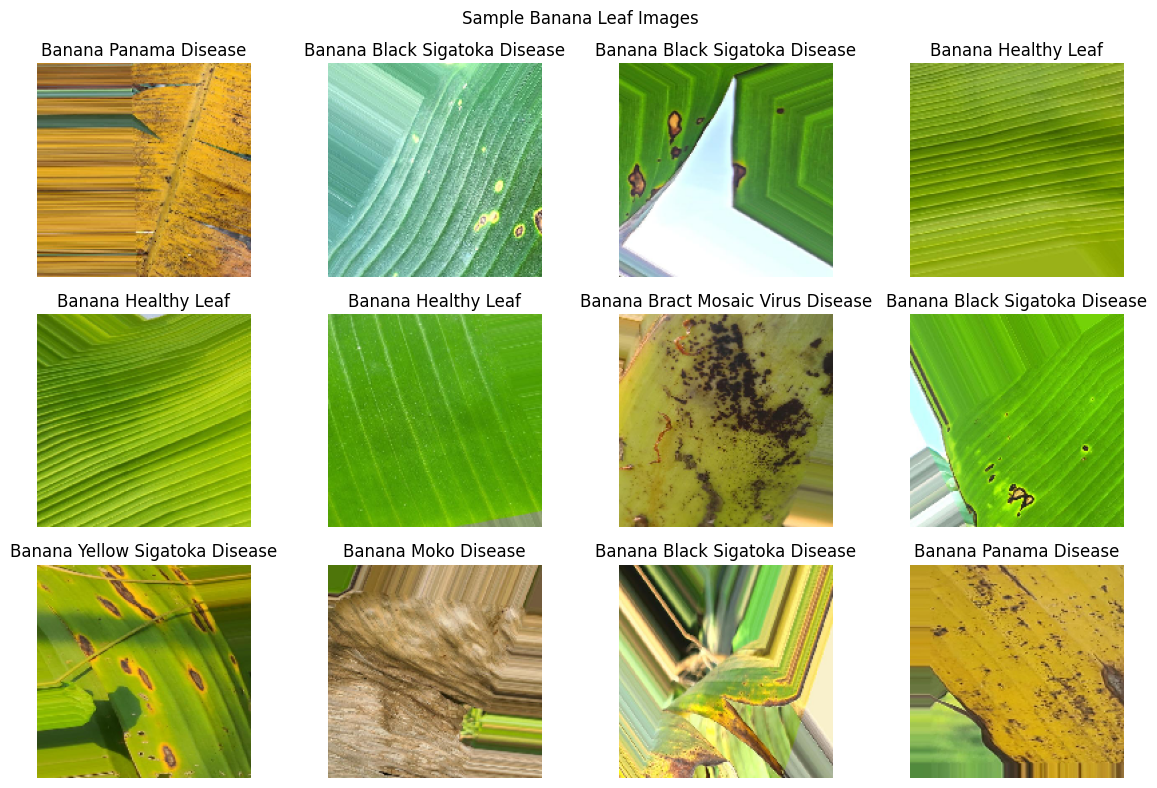

In [7]:
plt.figure(figsize=(12, 8))

sample_indices = random.sample(range(len(image_paths)), min(12, len(image_paths)))

for plot_index, image_index in enumerate(sample_indices):
    img = keras.utils.load_img(image_paths[image_index], target_size=(160, 160))
    label_name = index_to_class[int(labels[image_index])]

    plt.subplot(3, 4, plot_index + 1)
    plt.imshow(img)
    plt.title(label_name)
    plt.axis("off")

plt.suptitle("Sample Banana Leaf Images")
plt.tight_layout()
plt.show()

## Split into Training, Validation, and Testing

In [8]:
X_train = train_image_table["image_path"].to_numpy()
y_train = train_image_table["label_index"].to_numpy()

X_eval = eval_image_table["image_path"].to_numpy()
y_eval = eval_image_table["label_index"].to_numpy()

X_val, X_test, y_val, y_test = train_test_split(
    X_eval,
    y_eval,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_eval
)

print("Training images from augmented dataset:", len(X_train))
print("Validation images from original dataset:", len(X_val))
print("Testing images from original dataset:", len(X_test))

Training images from augmented dataset: 2856
Validation images from original dataset: 204
Testing images from original dataset: 204


## Distribution per Split

In [9]:
def make_split_distribution_table(y_values, split_name):
    temp_df = pd.DataFrame({"label_index": y_values})
    temp_df["Class"] = temp_df["label_index"].map(index_to_class)
    counts = temp_df["Class"].value_counts().reindex(class_names, fill_value=0)

    return pd.DataFrame({
        "Class": counts.index,
        split_name: counts.values
    })

train_dist = make_split_distribution_table(y_train, "Training")
val_dist = make_split_distribution_table(y_val, "Validation")
test_dist = make_split_distribution_table(y_test, "Testing")

distribution_table = train_dist.merge(val_dist, on="Class").merge(test_dist, on="Class")
distribution_table["Original Eval Total"] = distribution_table["Validation"] + distribution_table["Testing"]

print(distribution_table.to_string(index=False))

                            Class  Training  Validation  Testing  Original Eval Total
    Banana Black Sigatoka Disease       469          33       34                   67
Banana Bract Mosaic Virus Disease       350          25       25                   50
              Banana Healthy Leaf       602          43       43                   86
       Banana Insect Pest Disease       602          43       43                   86
              Banana Moko Disease       385          28       27                   55
            Banana Panama Disease       287          20       21                   41
   Banana Yellow Sigatoka Disease       161          12       11                   23


## TensorFlow Dataset Pipeline

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_image_raw(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label

def create_tf_dataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image_raw, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

train_ds = create_tf_dataset(X_train, y_train, shuffle=True)
val_ds = create_tf_dataset(X_val, y_val, shuffle=False)
test_ds = create_tf_dataset(X_test, y_test, shuffle=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## Data Augmentation for Training Only

In [11]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
        layers.RandomTranslation(0.05, 0.05),
    ],
    name="data_augmentation"
)

## Build Improved CNN Model

In [12]:
def build_leaf_disease_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
            data_augmentation,
            layers.Rescaling(1.0 / 255.0),

            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),

            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.40),
            layers.Dense(num_classes, activation="softmax")
        ],
        name="Banana_Leaf_Disease_CNN"
    )
    return model

model = build_leaf_disease_cnn()
model.summary()

Model: "Banana_Leaf_Disease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           1,799 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 457,927 (1.75 MB)

 Trainable params: 456,967 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## Compile Model

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train Model

In [14]:
EPOCHS = 20

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5055 - loss: 1.3407 - val_accuracy: 0.2108 - val_loss: 2.9480 - learning_rate: 0.0010
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6316 - loss: 0.9214 - val_accuracy: 0.2108 - val_loss: 3.7383 - learning_rate: 0.0010
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.7426 - loss: 0.6657 - val_accuracy: 0.2108 - val_loss: 5.8426 - learning_rate: 0.0010
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7764 - loss: 0.5845 - val_accuracy: 0.2108 - val_loss: 5.1432 - learning_rate: 0.0010
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8539 - loss: 0.3917 - val_accuracy: 0.4167 - val_loss: 2.0872 - learning_rate: 3.0000e-04
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8828 - loss: 0.3138 - val_accuracy: 0.7010 - val_loss: 0.7705 - learning_rate: 3.0000e-04
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9077 - loss: 0.2696 - 

## Plot Training Curves

 accuracy   loss  val_accuracy  val_loss  learning_rate
   0.5550 1.1369        0.2108    2.9480         0.0010
   0.6607 0.8600        0.2108    3.7383         0.0010
   0.7454 0.6527        0.2108    5.8426         0.0010
   0.8004 0.5302        0.2108    5.1432         0.0010
   0.8666 0.3708        0.4167    2.0872         0.0003
   0.8841 0.3171        0.7010    0.7705         0.0003
   0.9041 0.2794        0.8922    0.2486         0.0003
   0.9041 0.2588        0.8676    0.3400         0.0003
   0.9020 0.2591        0.8971    0.2358         0.0003
   0.9177 0.2270        0.9265    0.1809         0.0003
   0.9170 0.2293        0.9314    0.1455         0.0003
   0.9216 0.2271        0.8922    0.2849         0.0003
   0.9405 0.1709        0.8775    0.3488         0.0003
   0.9261 0.1997        0.9412    0.1496         0.0003
   0.9503 0.1398        0.9412    0.1267         0.0001
   0.9594 0.1311        0.9510    0.1178         0.0001
   0.9632 0.1142        0.9902    0.0702        

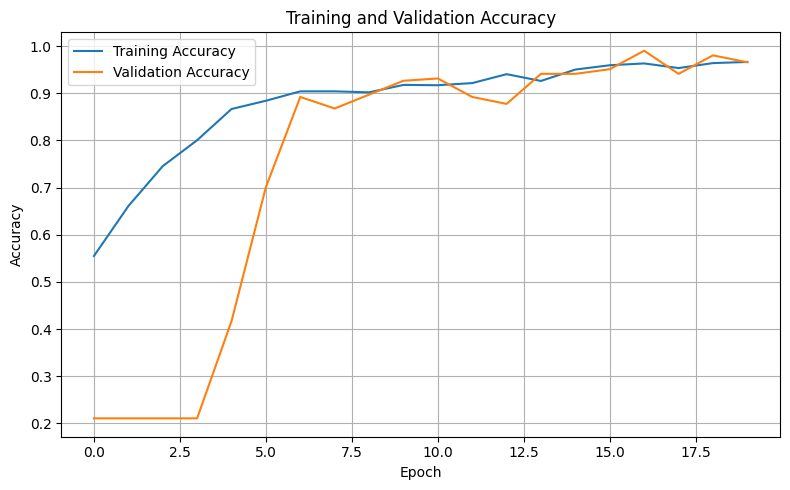

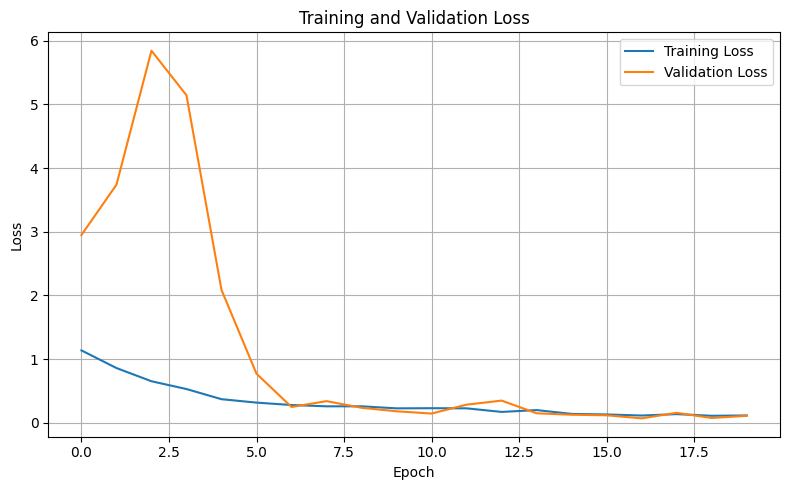

In [15]:
history_df = pd.DataFrame(history.history)

print(history_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluate on Test Set

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.9701 - loss: 0.0911
Test Loss: 0.1086
Test Accuracy: 0.9608


## Generate Predictions

In [17]:
y_true = []
y_pred = []
y_confidence = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)

    batch_pred = np.argmax(predictions, axis=1)
    batch_confidence = np.max(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(batch_pred)
    y_confidence.extend(batch_confidence)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_confidence = np.array(y_confidence)

print("Predictions generated:", len(y_pred))

Predictions generated: 204


## Classification Report

In [18]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print(report_df.round(4).to_string())

                                   precision  recall  f1-score   support
Banana Black Sigatoka Disease         1.0000  0.8824    0.9375   34.0000
Banana Bract Mosaic Virus Disease     1.0000  0.8800    0.9362   25.0000
Banana Healthy Leaf                   1.0000  1.0000    1.0000   43.0000
Banana Insect Pest Disease            0.9348  1.0000    0.9663   43.0000
Banana Moko Disease                   0.8667  0.9630    0.9123   27.0000
Banana Panama Disease                 0.9545  1.0000    0.9767   21.0000
Banana Yellow Sigatoka Disease        1.0000  1.0000    1.0000   11.0000
accuracy                              0.9608  0.9608    0.9608    0.9608
macro avg                             0.9651  0.9608    0.9613  204.0000
weighted avg                          0.9639  0.9608    0.9607  204.0000


## Confusion Matrix

                                         Predicted: Banana Black Sigatoka Disease  Predicted: Banana Bract Mosaic Virus Disease  Predicted: Banana Healthy Leaf  Predicted: Banana Insect Pest Disease  Predicted: Banana Moko Disease  Predicted: Banana Panama Disease  Predicted: Banana Yellow Sigatoka Disease
True: Banana Black Sigatoka Disease                                            30                                             0                               0                                      3                               1                                 0                                          0
True: Banana Bract Mosaic Virus Disease                                         0                                            22                               0                                      0                               3                                 0                                          0
True: Banana Healthy Leaf                                                   

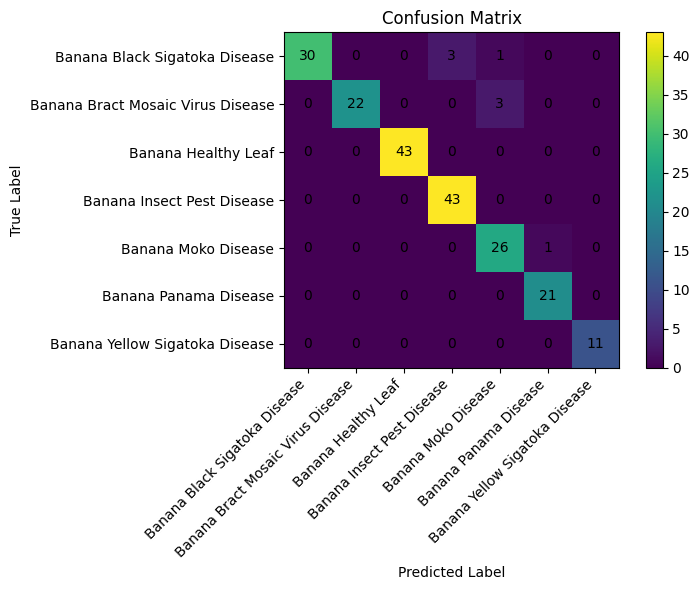

In [19]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {name}" for name in class_names],
    columns=[f"Predicted: {name}" for name in class_names]
)

print(cm_df.to_string())

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Build Results Table

In [20]:
results_df = pd.DataFrame({
    "Image Path": X_test,
    "True Label Index": y_true,
    "Predicted Label Index": y_pred,
    "Confidence": y_confidence
})

results_df["True Label"] = results_df["True Label Index"].map(index_to_class)
results_df["Predicted Label"] = results_df["Predicted Label Index"].map(index_to_class)
results_df["Correct"] = results_df["True Label Index"] == results_df["Predicted Label Index"]

print("Total test images:", len(results_df))
print("Correct predictions:", int(results_df["Correct"].sum()))
print("Wrong predictions:", int((~results_df["Correct"]).sum()))
print("Test accuracy from result table:", round(results_df["Correct"].mean(), 4))

Total test images: 204
Correct predictions: 196
Wrong predictions: 8
Test accuracy from result table: 0.9608


## Correct and Wrong Count per Class

In [21]:
correct_wrong_table = results_df.groupby("True Label")["Correct"].value_counts().unstack(fill_value=0)

if True not in correct_wrong_table.columns:
    correct_wrong_table[True] = 0

if False not in correct_wrong_table.columns:
    correct_wrong_table[False] = 0

correct_wrong_table = correct_wrong_table.rename(columns={
    True: "Correct",
    False: "Wrong"
})

correct_wrong_table["Total"] = correct_wrong_table["Correct"] + correct_wrong_table["Wrong"]
correct_wrong_table["Accuracy per Class"] = (
    correct_wrong_table["Correct"] / correct_wrong_table["Total"]
).round(4)

print(correct_wrong_table.to_string())

Correct                            Wrong  Correct  Total  Accuracy per Class
True Label                                                                  
Banana Black Sigatoka Disease          4       30     34              0.8824
Banana Bract Mosaic Virus Disease      3       22     25              0.8800
Banana Healthy Leaf                    0       43     43              1.0000
Banana Insect Pest Disease             0       43     43              1.0000
Banana Moko Disease                    1       26     27              0.9630
Banana Panama Disease                  0       21     21              1.0000
Banana Yellow Sigatoka Disease         0       11     11              1.0000


## Show Wrong Predictions

Number of wrong predictions: 8


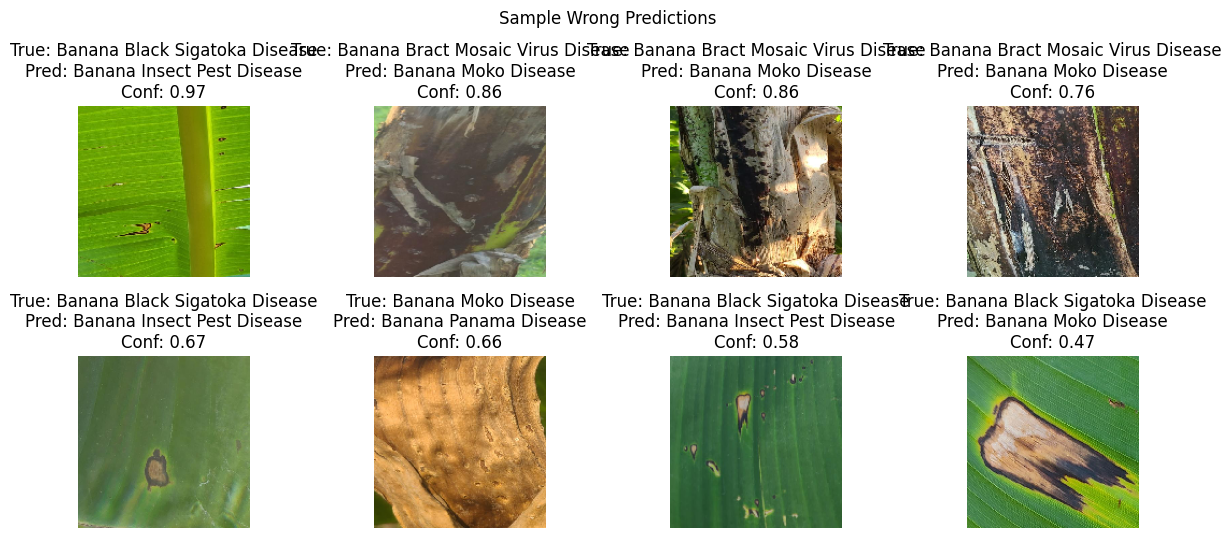

In [22]:
wrong_predictions = results_df[results_df["Correct"] == False].copy()
wrong_predictions = wrong_predictions.sort_values("Confidence", ascending=False)

print("Number of wrong predictions:", len(wrong_predictions))

sample_wrong = wrong_predictions.head(12)

if len(sample_wrong) == 0:
    print("No wrong predictions found.")
else:
    plt.figure(figsize=(12, 8))

    for plot_index, (_, row) in enumerate(sample_wrong.iterrows()):
        img = keras.utils.load_img(row["Image Path"], target_size=(160, 160))

        plt.subplot(3, 4, plot_index + 1)
        plt.imshow(img)
        plt.title(
            f"True: {row['True Label']}\n"
            f"Pred: {row['Predicted Label']}\n"
            f"Conf: {row['Confidence']:.2f}"
        )
        plt.axis("off")

    plt.suptitle("Sample Wrong Predictions")
    plt.tight_layout()
    plt.show()

## Single Image Prediction Function

{
    "predicted_class": "Banana Panama Disease",
    "confidence": 0.9965195655822754,
    "all_probabilities": {
        "Banana Black Sigatoka Disease": 2.0444747860892676e-05,
        "Banana Bract Mosaic Virus Disease": 0.0034426050260663033,
        "Banana Healthy Leaf": 7.059445476104154e-12,
        "Banana Insect Pest Disease": 3.3096911877805724e-09,
        "Banana Moko Disease": 1.7153823137050495e-05,
        "Banana Panama Disease": 0.9965195655822754,
        "Banana Yellow Sigatoka Disease": 1.8623781272708584e-07
    }
}


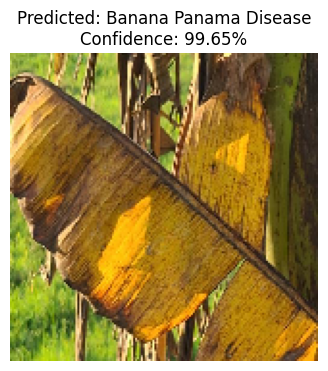

In [23]:
def predict_leaf_disease(image_path, model=model):
    image = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    image_array = keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    predicted_index = int(np.argmax(prediction))
    predicted_class = index_to_class[predicted_index]
    confidence = float(np.max(prediction))

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "all_probabilities": {
            index_to_class[i]: float(prediction[i])
            for i in range(len(class_names))
        }
    }

sample_image = X_test[0]
prediction_result = predict_leaf_disease(sample_image)

print(json.dumps(prediction_result, indent=4))

img = keras.utils.load_img(sample_image, target_size=(160, 160))
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(
    f"Predicted: {prediction_result['predicted_class']}\n"
    f"Confidence: {prediction_result['confidence']:.2%}"
)
plt.axis("off")
plt.show()

## Basic Recommendation Logic

In [24]:
def get_leaf_recommendation(predicted_class):
    name = predicted_class.lower()

    if "healthy" in name:
        return "The leaf appears healthy based on the trained model."

    if "sigatoka" in name:
        return "The leaf shows symptoms similar to Sigatoka. Field verification and disease management are recommended."

    if "mosaic" in name:
        return "The leaf shows mosaic-like symptoms. Inspect surrounding plants and verify possible viral spread."

    if "panama" in name or "fusarium" in name:
        return "The model suggests Panama or Fusarium-related symptoms. Immediate field inspection is recommended."

    if "moko" in name:
        return "The leaf may be associated with Moko disease. Check plant condition and nearby spread indicators."

    if "pest" in name or "insect" in name:
        return "The model suggests pest-related damage. Inspect for feeding marks and visible insect activity."

    return "The leaf shows abnormal symptoms. Manual inspection is recommended."

recommendation = get_leaf_recommendation(prediction_result["predicted_class"])

print("Predicted class:", prediction_result["predicted_class"])
print("Recommendation:", recommendation)

Predicted class: Banana Panama Disease
Recommendation: The model suggests Panama or Fusarium-related symptoms. Immediate field inspection is recommended.


## Save Model for Django Integration

In [27]:
SAVE_FOR_DJANGO = True

if SAVE_FOR_DJANGO:
    output_folder = Path("banana_leaf_model_export_1")
    output_folder.mkdir(exist_ok=True)

    model_path = output_folder / "banana_leaf_disease_model.keras"
    labels_path = output_folder / "class_labels.json"
    metadata_path = output_folder / "model_metadata.json"

    model.save(model_path)

    with open(labels_path, "w", encoding="utf-8") as file:
        json.dump(index_to_class, file, indent=4)

    metadata = {
        "project_title": "SagingSense PH: Banana Leaf Disease Classification Using Convolutional Neural Networks_1",
        "model_name": "Banana_Leaf_Disease_CNN_1",
        "image_size": IMG_SIZE,
        "number_of_classes": num_classes,
        "class_names": class_names,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "test_accuracy": float(test_accuracy)
    }

    with open(metadata_path, "w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=4)

    print("Export completed.")
    print("Saved model:", model_path)
    print("Saved labels:", labels_path)
    print("Saved metadata:", metadata_path)
else:
    print("SAVE_FOR_DJANGO is set to False.")

Export completed.
Saved model: banana_leaf_model_export_1\banana_leaf_disease_model.keras
Saved labels: banana_leaf_model_export_1\class_labels.json
Saved metadata: banana_leaf_model_export_1\model_metadata.json


## Final Summary

In [28]:
print("=" * 80)
print("BANANA LEAF DISEASE NOTEBOOK SUMMARY")
print("=" * 80)

print("\nTraining dataset folder:")
print(TRAIN_DATA_DIR)

print("\nEvaluation dataset folder:")
print(EVAL_DATA_DIR)

print("\nTraining images:")
print(train_total_images)

print("\nEvaluation images:")
print(eval_total_images)

print("\nClasses:")
for class_name in class_names:
    print("-", class_name)

print("\nDataset summary:")
print(dataset_summary.to_string(index=False))

print("\nTest accuracy:", round(test_accuracy, 4))

print("\nClassification report:")
print(report_df.round(4).to_string())

BANANA LEAF DISEASE NOTEBOOK SUMMARY

Training dataset folder:
kaggle\input\banana-disease-recognition-dataset\Augmented images\Augmented images

Evaluation dataset folder:
kaggle\input\banana-disease-recognition-dataset\Original Images\Original Images

Training images:
2856

Evaluation images:
408

Classes:
- Banana Black Sigatoka Disease
- Banana Bract Mosaic Virus Disease
- Banana Healthy Leaf
- Banana Insect Pest Disease
- Banana Moko Disease
- Banana Panama Disease
- Banana Yellow Sigatoka Disease

Dataset summary:
                            Class  Training Image Count  Evaluation Image Count  Total Image Count  Training Percentage  Evaluation Percentage
    Banana Black Sigatoka Disease                   469                      67                536                16.42                  16.42
Banana Bract Mosaic Virus Disease                   350                      50                400                12.25                  12.25
              Banana Healthy Leaf            